# Tutorial on using Radial Basis Functions (RBF) for path encoding

The `robotblockset.rbf` module provides a compact set of tools for encoding paths with Gaussian radial basis functions (RBF), decoding those paths again, estimating derivatives, and updating the approximation online.

This notebook explains the complete module through small runnable examples. The focus is on the practical workflow used in RBS:

1. start from measured or designed samples
2. encode them with `encodeRBF`
3. decode them again with `decodeRBF`, `decodeQuaternionRBF`, or `decodeCartesianRBF`
4. estimate derivative information with `jacobiRBF`
5. refine the model online with `updateRBF`


## Function Reference

The table below lists all public functions in `robotblockset.rbf` together with simplified call signatures and a short description.

| Function | Description |
| --- | --- |
| `encodeRBF(x, y, N=25, c=None, sigma2=None, bc=None, coff=0.02, sfac=3.0)` | Fit Gaussian RBF weights to sampled signals or paths. |
| `decodeRBF(x, RBF, calc_derivative=0)` | Evaluate an encoded RBF model and optionally return derivatives up to jerk. |
| `decodeQuaternionRBF(x, RBF)` | Decode an RBF model whose outputs represent quaternion components and renormalize them. |
| `decodeCartesianRBF(x, RBF)` | Decode an RBF model whose outputs represent Cartesian poses `(p, q)` and renormalize the quaternion part. |
| `jacobiRBF(x, RBF, deps=1e-5)` | Estimate the Jacobian of an RBF path and the derivative of that Jacobian by finite differences. |
| `updateRBF(x, yn, RBF)` | Update RBF weights online using recursive regression. |


## Imports

The examples below combine the RBF tools with a few helpers from `transformations.py`, `graphics.py`, and `tools.py` so the results can be visualized in the same style as the rest of the RBS tutorials.


In [1]:
%matplotlib inline

import copy
import numpy as np
import matplotlib.pyplot as plt

from robotblockset.rbf import encodeRBF, decodeRBF, decodeQuaternionRBF, decodeCartesianRBF, jacobiRBF, updateRBF
from robotblockset.transformations import prpy2x, rot_z
from robotblockset.graphics import plotcpath, plotpathpoints
from robotblockset.tools import gradientPath

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


In [2]:
# Shared sample domains and measured data.

x_meas = np.linspace(0.0, 1.0, 80)
x_eval = np.linspace(0.0, 1.0, 300)

# Two-channel signal used for the generic encode/decode examples.
y_meas = np.column_stack([
    np.sin(2 * np.pi * x_meas),
    0.4 * np.cos(4 * np.pi * x_meas) + 0.2 * x_meas,
])

# Boundary conditions for the previous signal:
# [ydot(0), ydot(end), yddot(0), yddot(end)]
bc_signal = np.array([
    [0.0, 0.0],
    [0.0, 0.0],
    [0.0, 0.0],
    [0.0, 0.0],
])

# Quaternion path generated from a yaw rotation.
yaw_meas = 1.2 * np.pi * x_meas
q_meas = np.array([rot_z(angle) for angle in yaw_meas])

# Cartesian path in pose form [x, y, z, qw, qx, qy, qz].
cartesian_prpy = np.column_stack([
    -0.25 + 0.55 * x_meas,
     0.10 * np.sin(2 * np.pi * x_meas),
     0.12 + 0.18 * x_meas,
     0.15 * np.sin(2 * np.pi * x_meas),
     0.10 * np.cos(np.pi * x_meas),
     1.10 * x_meas,
])
x_cart_meas = prpy2x(cartesian_prpy)


## 1. Encoding a sampled signal with `encodeRBF`

`encodeRBF` is the entry point of the module. It takes a path parameter `x`, measured samples `y`, and a chosen number of Gaussian kernels `N`. The result is a dictionary containing the kernel centers, widths, and fitted weights.

In most use cases only `x`, `y`, and `N` are needed. The optional parameters `c`, `sigma2`, and `bc` are useful when you want more control over the approximation.


In [3]:
rbf_signal = encodeRBF(x_meas, y_meas, N=18)

print("RBF keys:", sorted(rbf_signal.keys()))
print("number of kernels:", rbf_signal["N"])
print("weights shape:", rbf_signal["w"].shape)
print("centers shape:", rbf_signal["c"].shape)
print("sigma2 shape:", rbf_signal["sigma2"].shape)


RBF keys: ['N', 'c', 'sigma2', 'w']
number of kernels: 18
weights shape: (18, 2)
centers shape: (18,)
sigma2 shape: (18,)


A useful first check is to decode the approximation again and compare it to the original samples.


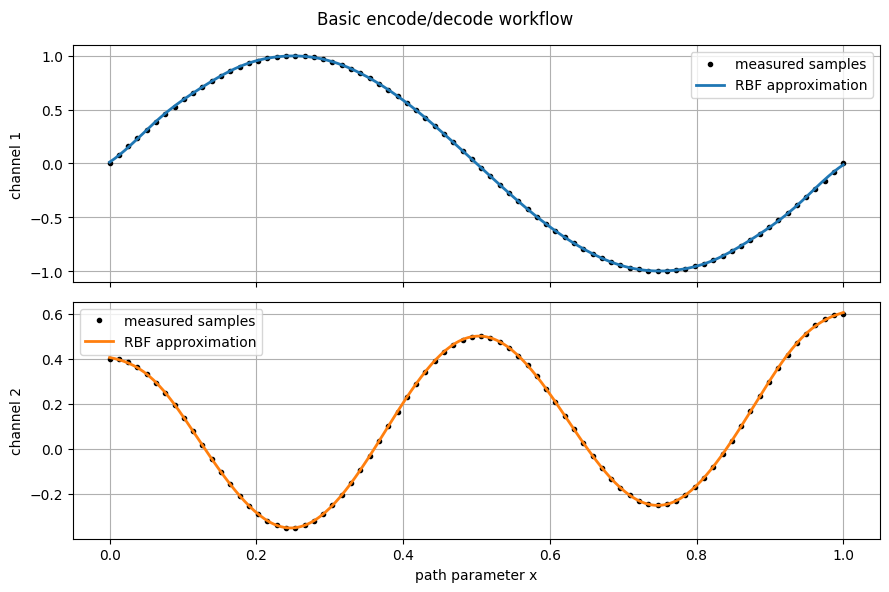

In [4]:
y_rbf = decodeRBF(x_eval, rbf_signal)

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
labels = ["channel 1", "channel 2"]
for i in range(2):
    ax[i].plot(x_meas, y_meas[:, i], "k.", label="measured samples")
    ax[i].plot(x_eval, y_rbf[:, i], color=f"C{i}", linewidth=2, label="RBF approximation")
    ax[i].set_ylabel(labels[i])
    ax[i].legend(loc="best")
ax[-1].set_xlabel("path parameter x")
fig.suptitle("Basic encode/decode workflow")
plt.tight_layout()
plt.show()


## 2. Boundary conditions in `encodeRBF`

Compared to simple interpolation, the RBF encoding can include initial and final derivative constraints through the `bc` argument. This is useful when the path must start and end with known velocity or acceleration behavior.

The next example compares a plain RBF fit against one that enforces zero start and end derivatives.


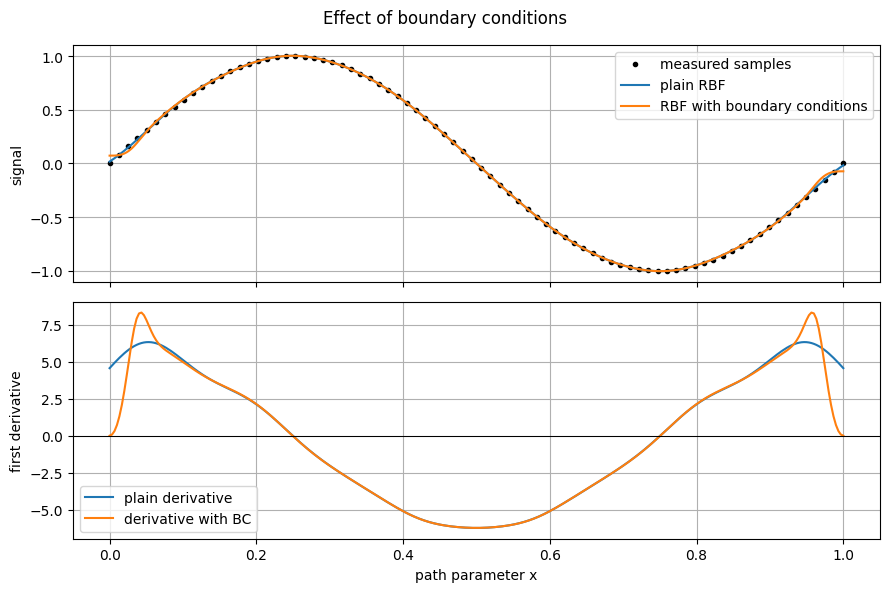

In [5]:
rbf_plain = encodeRBF(x_meas, y_meas[:, [0]], N=14)
rbf_bc = encodeRBF(x_meas, y_meas[:, [0]], N=14, bc=bc_signal[:, [0]])

y_plain, yd_plain = decodeRBF(x_eval, rbf_plain, calc_derivative=1)
y_bc, yd_bc = decodeRBF(x_eval, rbf_bc, calc_derivative=1)

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax[0].plot(x_meas, y_meas[:, 0], "k.", label="measured samples")
ax[0].plot(x_eval, y_plain[:, 0], label="plain RBF")
ax[0].plot(x_eval, y_bc[:, 0], label="RBF with boundary conditions")
ax[0].set_ylabel("signal")
ax[0].legend(loc="best")

ax[1].plot(x_eval, yd_plain[:, 0], label="plain derivative")
ax[1].plot(x_eval, yd_bc[:, 0], label="derivative with BC")
ax[1].axhline(0.0, color="k", linewidth=0.75)
ax[1].set_xlabel("path parameter x")
ax[1].set_ylabel("first derivative")
ax[1].legend(loc="best")
fig.suptitle("Effect of boundary conditions")
plt.tight_layout()
plt.show()


## 3. Derivatives with `decodeRBF`

`decodeRBF` can return more than just the path values. With `calc_derivative` set to `1`, `2`, or `3`, it also returns velocity, acceleration, and jerk of the decoded signal.

This is one of the most useful parts of the module because it gives a smooth parametric representation together with derivative information from the same RBF model.


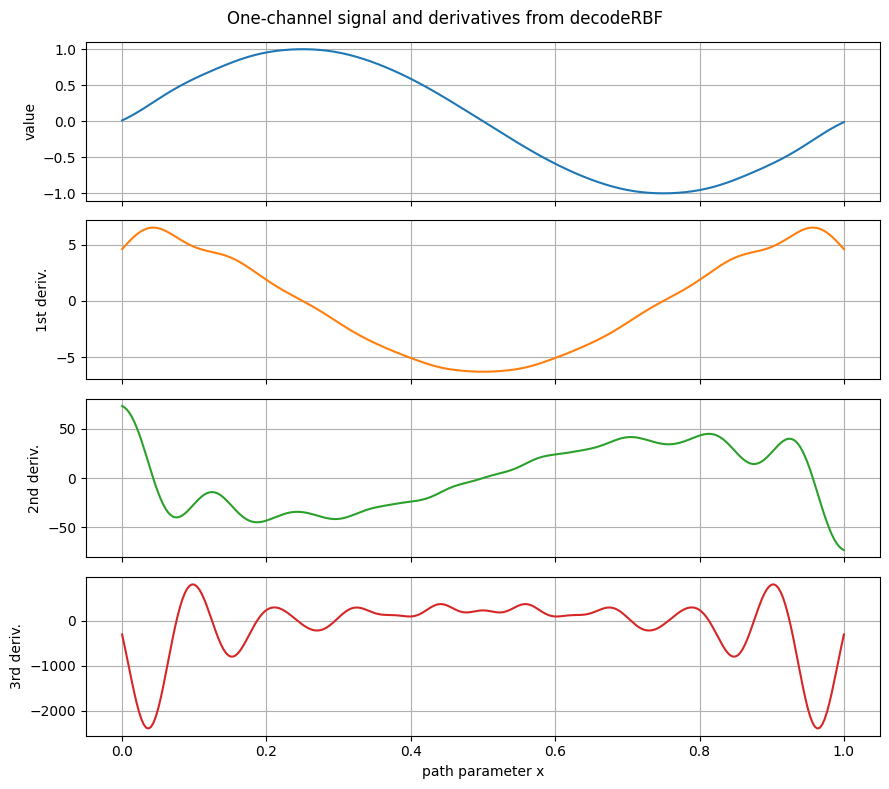

In [6]:
y_dec, yd_dec, ydd_dec, yddd_dec = decodeRBF(x_eval, rbf_signal, calc_derivative=3)

fig, ax = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
ax[0].plot(x_eval, y_dec[:, 0], label="y")
ax[0].set_ylabel("value")
ax[1].plot(x_eval, yd_dec[:, 0], label="ydot", color="C1")
ax[1].set_ylabel("1st deriv.")
ax[2].plot(x_eval, ydd_dec[:, 0], label="yddot", color="C2")
ax[2].set_ylabel("2nd deriv.")
ax[3].plot(x_eval, yddd_dec[:, 0], label="ydddot", color="C3")
ax[3].set_ylabel("3rd deriv.")
ax[3].set_xlabel("path parameter x")
fig.suptitle("One-channel signal and derivatives from decodeRBF")
plt.tight_layout()
plt.show()


## 4. Quaternion paths with `decodeQuaternionRBF`

Quaternion components can be encoded with `encodeRBF` like any other signal. The difference comes at decoding time: `decodeQuaternionRBF` normalizes the output so the result stays on the unit quaternion sphere.

The next example approximates a yaw rotation and checks the quaternion norm after decoding.


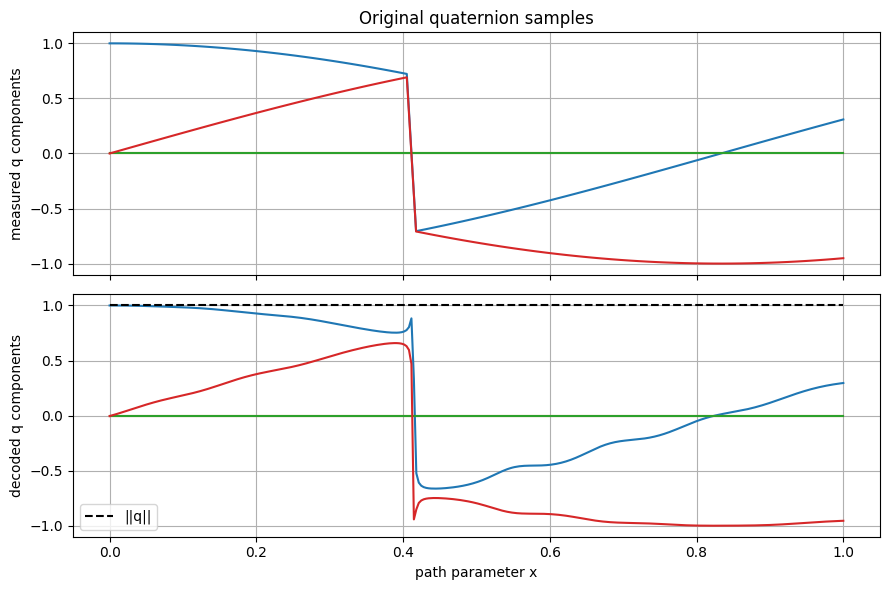

min quaternion norm: 0.9999999999999998
max quaternion norm: 1.0000000000000002


In [7]:
rbf_quat = encodeRBF(x_meas, q_meas, N=16)
q_rbf = decodeQuaternionRBF(x_eval, rbf_quat)
q_norm = np.linalg.norm(q_rbf, axis=1)

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax[0].plot(x_meas, q_meas)
ax[0].set_ylabel("measured q components")
ax[0].set_title("Original quaternion samples")

ax[1].plot(x_eval, q_rbf)
ax[1].plot(x_eval, q_norm, "k--", linewidth=1.5, label="||q||")
ax[1].set_ylabel("decoded q components")
ax[1].set_xlabel("path parameter x")
ax[1].legend(loc="best")
plt.tight_layout()
plt.show()

print("min quaternion norm:", q_norm.min())
print("max quaternion norm:", q_norm.max())


## 5. Cartesian poses with `decodeCartesianRBF`

For robot paths the most common use case is a Cartesian pose path in the RBS pose representation `(p, q)`. `decodeCartesianRBF` is a thin convenience wrapper that decodes the seven pose coordinates and renormalizes the quaternion part.

This is the same pattern shown in the MATLAB README and in the motion-generation tutorial: encode a Cartesian path once, then decode it densely for plotting or for later execution.


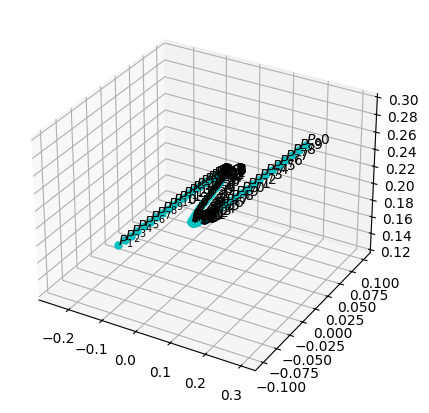

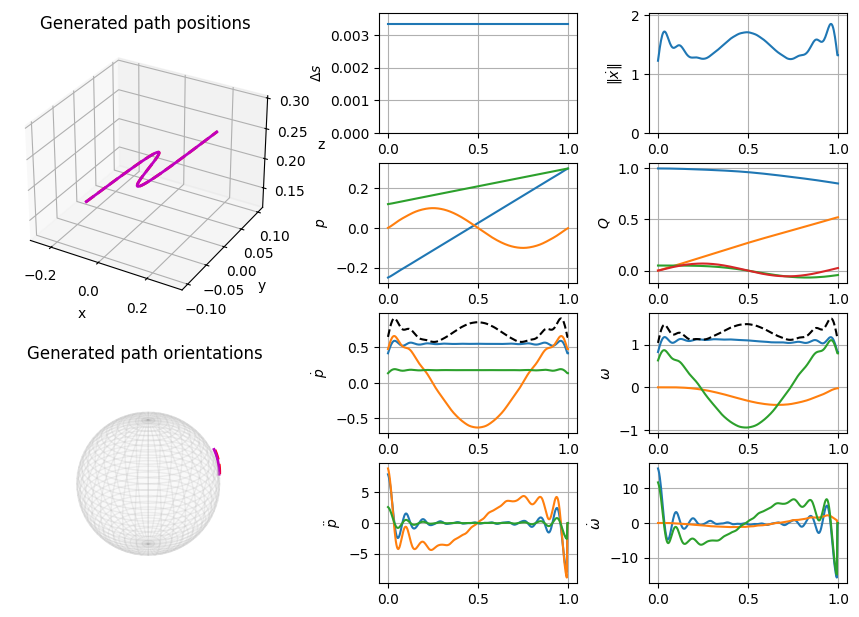

In [8]:
rbf_cart = encodeRBF(x_meas, x_cart_meas, N=22)
x_cart_rbf = decodeCartesianRBF(x_eval, rbf_cart)

plotpathpoints(x=x_cart_meas, label=True, fig_num="Measured Cartesian samples")
plt.show()

plotcpath(x_eval, x_cart_rbf, points=x_cart_meas, UCS=False, label=False, fig_num="Cartesian path from RBF")
plt.show()


## 6. Jacobian estimates with `jacobiRBF`

`jacobiRBF` computes the Jacobian of the decoded path with respect to the path parameter using finite differences. In the current implementation this means a numerical derivative of the decoded RBF output, plus a second finite difference for the Jacobian derivative.

For a multi-channel signal the returned Jacobian has one column per output channel.


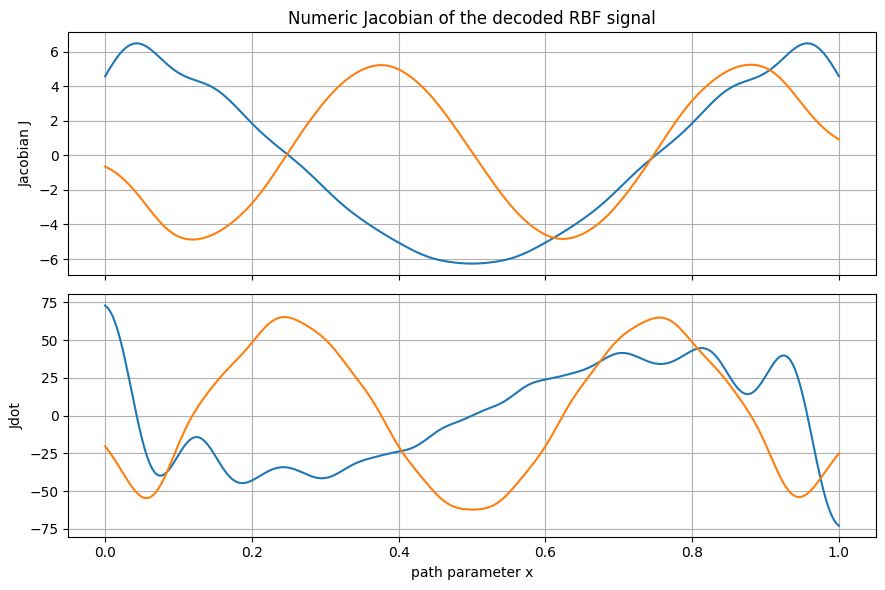

In [9]:
J, Jdot = jacobiRBF(x_eval, rbf_signal)

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax[0].plot(x_eval, J)
ax[0].set_ylabel("Jacobian J")
ax[0].set_title("Numeric Jacobian of the decoded RBF signal")
ax[1].plot(x_eval, Jdot)
ax[1].set_ylabel("Jdot")
ax[1].set_xlabel("path parameter x")
plt.tight_layout()
plt.show()


## 7. Online refinement with `updateRBF`

`updateRBF` is intended for recursive regression: one new sample at a time is used to update the fitted weights. To use it, the RBF dictionary must contain two additional entries:

- `p`: the recursive regression matrix
- `lambda`: the forgetting or regularization factor

The following example starts from an intentionally poor initial model and updates it sequentially with streaming samples.


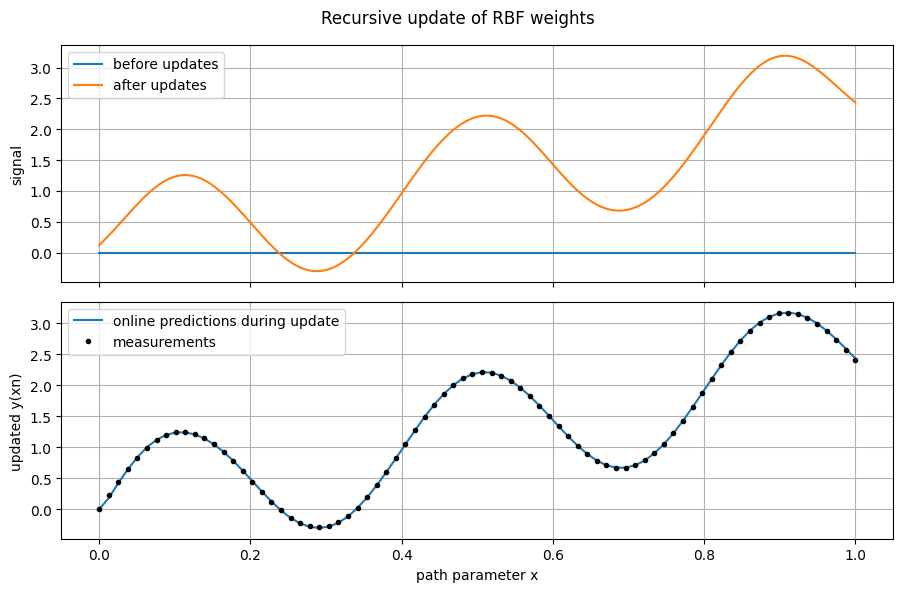

In [16]:
# Start from an intentionally poor initial model.
rbf_online = encodeRBF(x_meas, np.zeros((len(x_meas), 1)), N=12)
rbf_online["p"] = np.eye(rbf_online["N"]) * 500.0
rbf_online["lambda"] = 0.9


stream_target = (np.sin(5 * np.pi * x_meas)  + 2.4 * x_meas)[:, None]
y_before = decodeRBF(x_eval, copy.deepcopy(rbf_online))

predicted_stream = []
for xn, yn in zip(x_meas, stream_target):
    y_updated, rbf_online = updateRBF(xn, yn, rbf_online)
    predicted_stream.append(y_updated.ravel())

predicted_stream = np.array(predicted_stream)
y_after = decodeRBF(x_eval, rbf_online)

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax[0].plot(x_eval, y_before[:, 0], label="before updates")
ax[0].plot(x_eval, y_after[:, 0], label="after updates")
# ax[0].plot(x_meas, stream_target[:, 0], "k.", label="streamed measurements")
ax[0].set_ylabel("signal")
ax[0].legend(loc="best")

ax[1].plot(x_meas, predicted_stream[:, 0], label="online predictions during update")
ax[1].plot(x_meas, stream_target[:, 0], "k.", label="measurements")
ax[1].set_xlabel("path parameter x")
ax[1].set_ylabel("updated y(xn)")
ax[1].legend(loc="best")
fig.suptitle("Recursive update of RBF weights")
plt.tight_layout()
plt.show()


In [11]:
y_after[:5]

array([[0.0215],
       [0.0371],
       [0.0532],
       [0.0698],
       [0.0869]])

## 8. Typical RBS workflow for Cartesian paths

In practice the RBF tools are often used like this:

1. capture or generate a Cartesian path as pose samples
2. encode the samples with `encodeRBF`
3. decode a dense path with `decodeCartesianRBF`
4. use the decoded path for plotting, timing, or robot motion methods such as RBF-based path execution

The next short example mirrors that workflow in one cell.


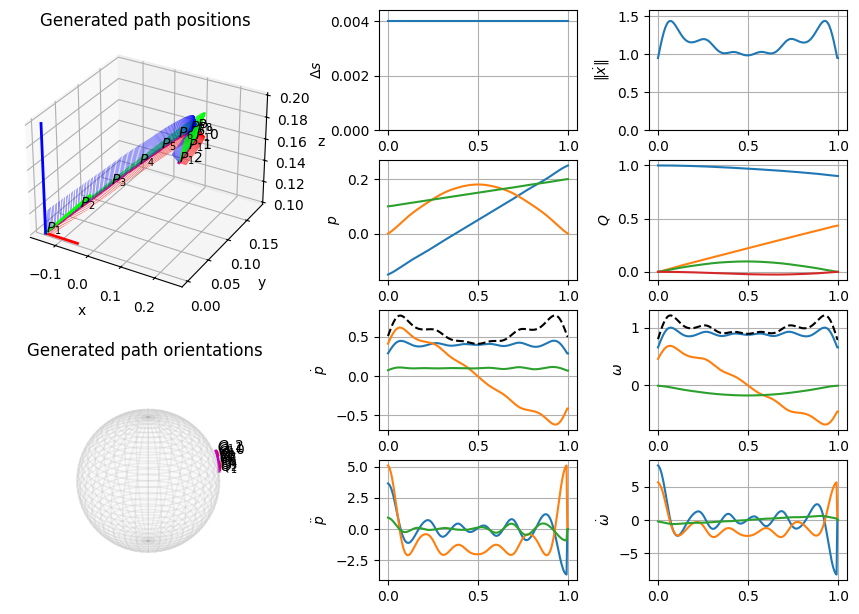

In [12]:
x_sparse = np.linspace(0.0, 1.0, 12)
poses_sparse = prpy2x(np.column_stack([
    -0.15 + 0.40 * x_sparse,
     0.18 * np.sin(np.pi * x_sparse),
     0.10 + 0.10 * x_sparse,
     0.00 * x_sparse,
     0.20 * np.sin(np.pi * x_sparse),
     0.90 * x_sparse,
]))

rbf_sparse = encodeRBF(x_sparse, poses_sparse, N=14)
x_dense = np.linspace(0.0, 1.0, 250)
poses_dense = decodeCartesianRBF(x_dense, rbf_sparse)

plotcpath(x_dense, poses_dense, points=poses_sparse, UCS=True, label=True, fig_num="Sparse poses encoded as RBF")
plt.show()
